In [3]:
# LIBRERIAS NECESARIAS
import os, random, shutil, glob, json, math, itertools, pathlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical, plot_model
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pathlib import Path



import os, glob
import os, random, glob, warnings
warnings.filterwarnings("ignore")
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

2025-10-01 21:26:37.990435: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 21:26:38.107420: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-01 21:26:39.353259: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-01 21:26:43.700683: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [4]:
# RUTAS 
BASE = Path("../data/raw/dog_vs_cat/dogs_vs_cats")
TRAIN_DIR = BASE / "train"
TEST_DIR  = BASE / "test"
PROCESSED = Path("../data/processed/full_data")


train_path = str(TRAIN_DIR)
test_path  = str(TEST_DIR)
processed_path = str(PROCESSED)

# Comprobaciones mínimas
assert TRAIN_DIR.is_dir(), f"No existe: {TRAIN_DIR}"
assert TEST_DIR.is_dir(),  f"No existe: {TEST_DIR}"
PROCESSED.mkdir(parents=True, exist_ok=True)

# Verificación: contamos imágenes posibles (soporta plano o subcarpetas)
cats = sorted(glob.glob(str(TRAIN_DIR / "cat.*.jpg"))) or sorted(glob.glob(str(TRAIN_DIR / "cat" / "*.jpg")))
dogs = sorted(glob.glob(str(TRAIN_DIR / "dog.*.jpg"))) or sorted(glob.glob(str(TRAIN_DIR / "dog" / "*.jpg")))

display(Markdown(f"**OK** · `{TRAIN_DIR}` → {len(cats)} cats, {len(dogs)} dogs.  \nProcesado en: `{PROCESSED}`"))


**OK** · `../data/raw/dog_vs_cat/dogs_vs_cats/train` → 0 cats, 0 dogs.  
Procesado en: `../data/processed/full_data`

In [6]:
# Diagnóstico (¿dónde están los cats/dogs?)
def find_class_files_anywhere(base_dir, cls):
    base_dir = os.path.abspath(base_dir)
    cls = cls.lower()
    files = []
    # 1) subcarpetas "cat"/"dog" (o plurales)
    for sub in ["cat", "cats", "dog", "dogs"]:
        if cls in sub:
            subdir = os.path.join(base_dir, sub)
            if os.path.isdir(subdir):
                for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
                    files += glob.glob(os.path.join(subdir, "**", ext), recursive=True)
    # 2) patrón plano: cat.*.jpg / dog.*.jpg
    for ext in (".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"):
        files += glob.glob(os.path.join(base_dir, f"{cls}.*{ext}"))
    # 3) búsqueda general por nombre de archivo o carpeta
    for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
        for p in glob.glob(os.path.join(base_dir, "**", ext), recursive=True):
            low = p.lower()
            parent = os.path.basename(os.path.dirname(p)).lower()
            if (cls in os.path.basename(low)) or (parent == cls or parent == f"{cls}s"):
                files.append(p)
    # únicos y ordenados
    files = sorted(list(set(files)))
    return files

cats_train = find_class_files_anywhere(train_path, "cat")
dogs_train = find_class_files_anywhere(train_path, "dog")
cats_test  = find_class_files_anywhere(test_path,  "cat")
dogs_test  = find_class_files_anywhere(test_path,  "dog")

display(Markdown(
    f"""
**Diagnóstico**

- `train_path`: **{train_path}**  
  • cats: **{len(cats_train)}**  
  • dogs: **{len(dogs_train)}**

- `test_path`: **{test_path}**  
  • cats: **{len(cats_test)}**  
  • dogs: **{len(dogs_test)}**

> Si en `test` salen 0/0, probablemente ese *test* está **sin etiquetas** (por ejemplo, ficheros `1.jpg, 2.jpg...`). En ese caso, no se puede añadir a entrenamiento.
"""
))





**Diagnóstico**

- `train_path`: **../data/raw/dog_vs_cat/dogs_vs_cats/train**  
  • cats: **3136**  
  • dogs: **0**

- `test_path`: **../data/raw/dog_vs_cat/dogs_vs_cats/test**  
  • cats: **13345**  
  • dogs: **5000**

> Si en `test` salen 0/0, probablemente ese *test* está **sin etiquetas** (por ejemplo, ficheros `1.jpg, 2.jpg...`). En ese caso, no se puede añadir a entrenamiento.


In [7]:
#Rehacer el split fusionando train + test
import os, shutil, numpy as np
from IPython.display import display, Markdown

CLASSES = ["cat","dog"]

# 1) Reunimos TODAS las imágenes etiquetadas desde train y test
cats_all = find_class_files_anywhere(train_path, "cat") + find_class_files_anywhere(test_path, "cat")
dogs_all = find_class_files_anywhere(train_path, "dog") + find_class_files_anywhere(test_path, "dog")

# 2) Si no hay ninguna en test, seguimos solo con train (esto es normal si test es anónimo)
if len(cats_all) == 0 or len(dogs_all) == 0:
    cats_all = find_class_files_anywhere(train_path, "cat")
    dogs_all = find_class_files_anywhere(train_path, "dog")

# 3) Reset del procesado (para evitar mezclas antiguas)
def reset_processed(root, classes):
    if os.path.isdir(root):
        shutil.rmtree(root)
    for split in ["train","valid","test"]:
        for cls in classes:
            os.makedirs(os.path.join(root, split, cls), exist_ok=True)

reset_processed(processed_path, CLASSES)

# 4) Split 80/10/10 y copiado
def split_copy(files, cls, dest_root, seed=42):
    files = sorted(list(set(files)))
    n = len(files)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    tr = int(0.8*n); va = int(0.9*n)
    parts = {
        "train": [files[i] for i in idx[:tr]],
        "valid": [files[i] for i in idx[tr:va]],
        "test":  [files[i] for i in idx[va:]],
    }
    for split, lst in parts.items():
        dest_dir = os.path.join(dest_root, split, cls)
        for src in lst:
            dst = os.path.join(dest_dir, os.path.basename(src))
            if not os.path.exists(dst):
                shutil.copy2(src, dst)

split_copy(cats_all, "cat", processed_path)
split_copy(dogs_all, "dog", processed_path)

# 5) Resumen
def count_in_dir(dir_):
    tot = 0
    for ext in ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"):
        tot += len(glob.glob(os.path.join(dir_, ext)))
    return tot

PROC_TRAIN = os.path.join(processed_path, "train")
PROC_VALID = os.path.join(processed_path, "valid")
PROC_TEST  = os.path.join(processed_path, "test")

summary_md = f"""
**Split creado en** `{processed_path}`

- train:  cat={count_in_dir(os.path.join(PROC_TRAIN, 'cat'))},  dog={count_in_dir(os.path.join(PROC_TRAIN, 'dog'))}
- valid:  cat={count_in_dir(os.path.join(PROC_VALID, 'cat'))},  dog={count_in_dir(os.path.join(PROC_VALID, 'dog'))}
- test:   cat={count_in_dir(os.path.join(PROC_TEST,  'cat'))},  dog={count_in_dir(os.path.join(PROC_TEST,  'dog'))}
"""
display(Markdown(summary_md))



**Split creado en** `../data/processed/full_data`

- train:  cat=9583,  dog=2404
- valid:  cat=1589,  dog=473
- test:   cat=1601,  dog=476


**Cats (original) — ../data/raw/dog_vs_cat/dogs_vs_cats/train** — 9 imágenes encontradas

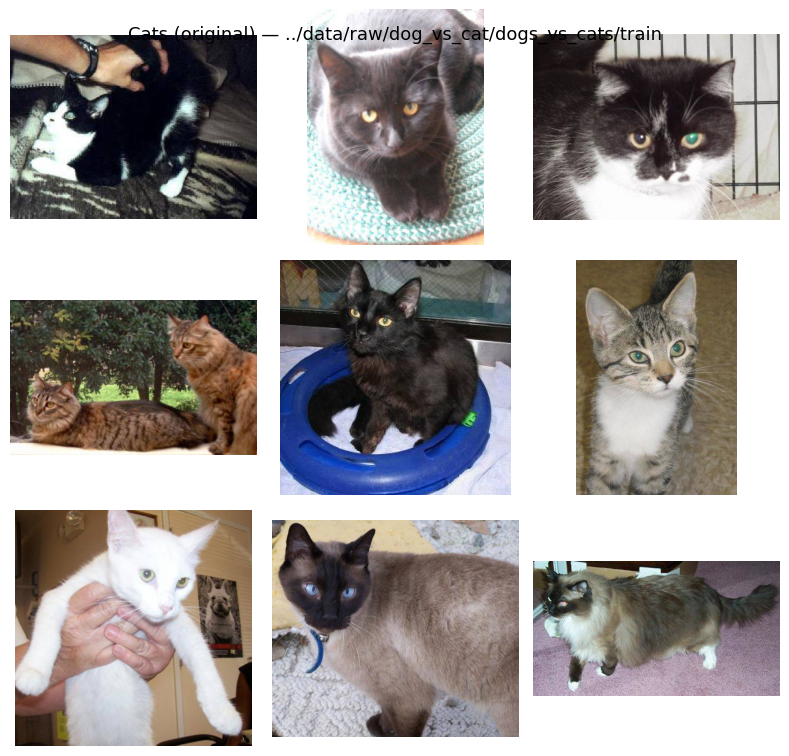

**Dogs (original) — ../data/raw/dog_vs_cat/dogs_vs_cats/train** — 0 imágenes encontradas

**Dogs (desde test) — ../data/raw/dog_vs_cat/dogs_vs_cats/test** — 9 imágenes encontradas

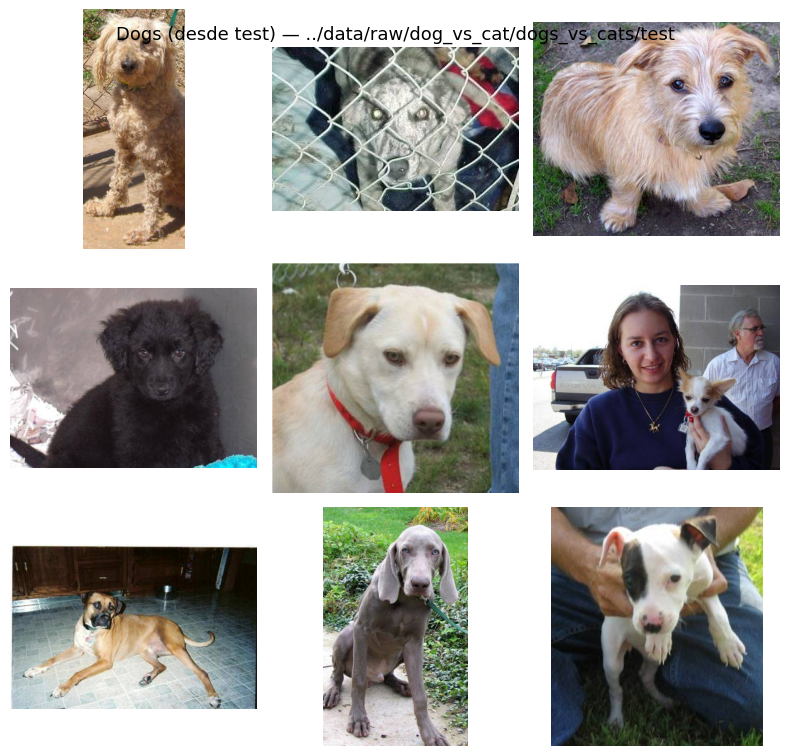

**Cats (processed/train) — ../data/processed/full_data/train** — 9 imágenes encontradas

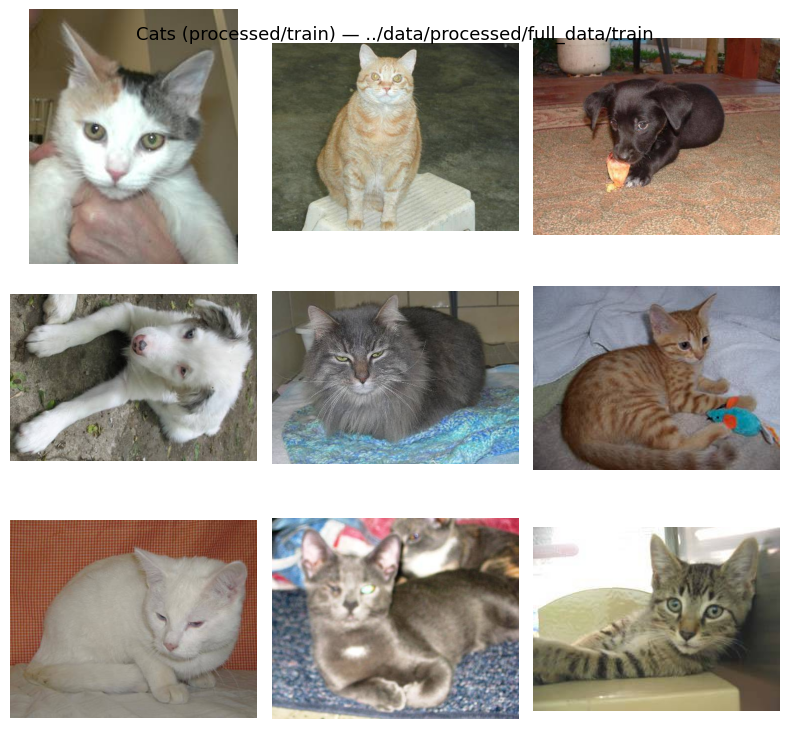

**Dogs (processed/train) — ../data/processed/full_data/train** — 9 imágenes encontradas

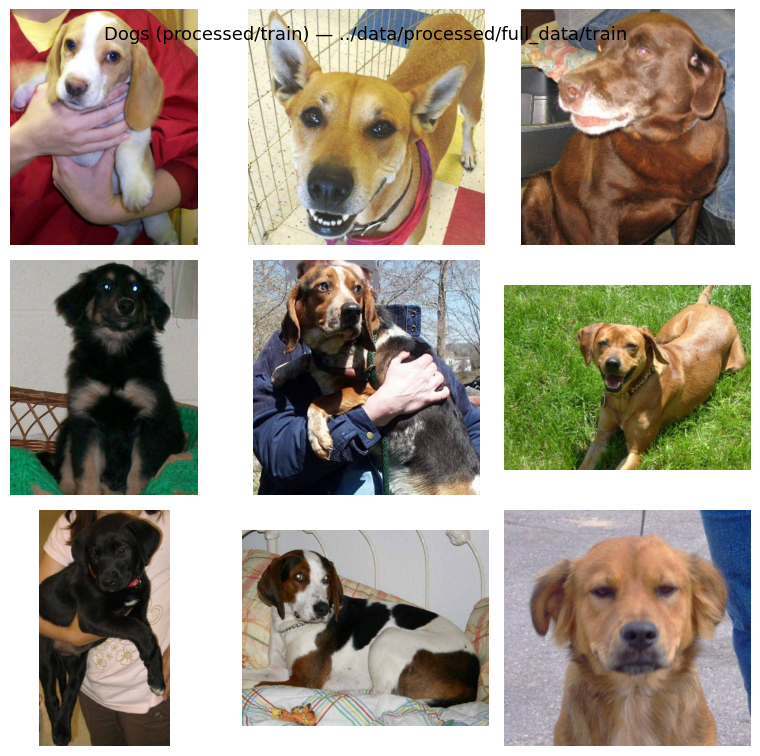

In [8]:
# Vista previa de imágenes (original y procesado)

def find_images_by_class(root, cls):
    """Busca imágenes por nombre de archivo o por carpeta (cat/dog), en cualquier subcarpeta."""
    root = os.path.abspath(root)
    matches = []
    cls = cls.lower()
    exts = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")
    for dirpath, _, filenames in os.walk(root):
        parent = os.path.basename(dirpath).lower()
        for fn in filenames:
            low = fn.lower()
            if low.endswith(exts) and (cls in low or parent == cls or parent == f"{cls}s"):
                matches.append(os.path.join(dirpath, fn))
    return sorted(list(set(matches)))

def preview(files, title, k=9):
    n = min(k, len(files))
    display(Markdown(f"**{title}** — {len(files)} imágenes encontradas"))
    if n == 0:
        return
    rows, cols = 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
    fig.suptitle(title, y=0.92, fontsize=13)
    for ax, p in zip(axes.ravel(), files[:n]):
        try:
            ax.imshow(Image.open(p))
        except Exception:
            ax.imshow([[0]])  # fallback si hay error al leer
        ax.set_axis_off()
    for ax in axes.ravel()[n:]:
        ax.set_axis_off()
    plt.tight_layout(); plt.show()

# -------- ORIGINAL (train_path) --------
cats_orig = find_images_by_class(train_path, "cat")
dogs_orig = find_images_by_class(train_path, "dog")
preview(random.sample(cats_orig, k=min(9, len(cats_orig))), f"Cats (original) — {train_path}")
preview(random.sample(dogs_orig, k=min(9, len(dogs_orig))), f"Dogs (original) — {train_path}")

# Si no hay dogs en train, intenta mostrarlos desde test 
if len(dogs_orig) == 0:
    dogs_test = find_images_by_class(test_path, "dog")
    preview(random.sample(dogs_test, k=min(9, len(dogs_test))), f"Dogs (desde test) — {test_path}")

# -------- PROCESADO (processed_path/train) --------
proc_train_dir = os.path.join(processed_path, "train")
cats_proc = find_images_by_class(proc_train_dir, "cat")
dogs_proc = find_images_by_class(proc_train_dir, "dog")
preview(random.sample(cats_proc, k=min(9, len(cats_proc))), f"Cats (processed/train) — {proc_train_dir}")
preview(random.sample(dogs_proc, k=min(9, len(dogs_proc))), f"Dogs (processed/train) — {proc_train_dir}")



In [9]:
# PROCESADO: dividir en train/valid/test
CLASSES = ["cat","dog"]
PROC_TRAIN = os.path.join(processed_path, "train")
PROC_VALID = os.path.join(processed_path, "valid")
PROC_TEST  = os.path.join(processed_path, "test")
for d in [PROC_TRAIN, PROC_VALID, PROC_TEST]:
    for c in CLASSES:
        os.makedirs(os.path.join(d, c), exist_ok=True)

def find_class_files(base_dir, cls_name):
    subdir = os.path.join(base_dir, cls_name)
    if os.path.isdir(subdir):  # /train/cat/*.jpg
        return sorted(sum([glob.glob(os.path.join(subdir, f"*{ext}")) for ext in (".jpg",".jpeg",".png")], []))
    # plano: /train/cat.0.jpg
    patterns = [f"{cls_name}.*{ext}" for ext in (".jpg",".jpeg",".png")]
    files = []
    for p in patterns:
        files += glob.glob(os.path.join(base_dir, p))
    return sorted(files)

def split_copy(files, cls, dest_root, seed=42):
    n = len(files)
    idx = np.arange(n); rng = np.random.default_rng(seed); rng.shuffle(idx)
    tr = int(0.8*n); va = int(0.9*n)
    parts = {
        "train": [files[i] for i in idx[:tr]],
        "valid": [files[i] for i in idx[tr:va]],
        "test":  [files[i] for i in idx[va:]],
    }
    for split, lst in parts.items():
        dest_dir = os.path.join(dest_root, split, cls)
        for src in lst:
            dst = os.path.join(dest_dir, os.path.basename(src))
            if not os.path.exists(dst):
                shutil.copy2(src, dst)

cats_all = find_class_files(train_path, "cat")
dogs_all = find_class_files(train_path, "dog")
split_copy(cats_all, "cat", processed_path)
split_copy(dogs_all, "dog", processed_path)


## Generadores (resize a 200×200 y etiquetado automático)

In [10]:
IMG_SIZE = (200, 200)
BATCH_SIZE = 32
CLASSES = ["cat","dog"]

PROC_TRAIN = os.path.join(processed_path, "train")
PROC_VALID = os.path.join(processed_path, "valid")
PROC_TEST  = os.path.join(processed_path, "test")

tr_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)
te_gen = ImageDataGenerator(rescale=1./255)

train_gen = tr_aug.flow_from_directory(
    PROC_TRAIN, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=42, classes=CLASSES
)
valid_gen = te_gen.flow_from_directory(
    PROC_VALID, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, classes=CLASSES
)
test_gen = te_gen.flow_from_directory(
    PROC_TEST, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, classes=CLASSES
)

steps_train = math.ceil(train_gen.samples / BATCH_SIZE)
steps_valid = math.ceil(valid_gen.samples / BATCH_SIZE)
steps_test  = math.ceil(test_gen.samples  / BATCH_SIZE)

# Guarda el mapping clase->índice (útil para inferencia)
with open(os.path.join(processed_path, "class_indices.json"), "w") as f:
    json.dump(train_gen.class_indices, f)


Found 11987 images belonging to 2 classes.
Found 2062 images belonging to 2 classes.
Found 2077 images belonging to 2 classes.


### Modelo CNN (VGG-style) y compilación

In [11]:
INPUT_SHAPE = (200, 200, 3)

model = Sequential()
model.add(Conv2D(input_shape=INPUT_SHAPE, filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(2, activation="softmax"))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


2025-10-01 21:42:13.158129: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
best_path = os.path.join(processed_path, "best_model.keras")
cbs = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ModelCheckpoint(best_path, monitor="val_accuracy", save_best_only=True)
]

EPOCHS = 25
history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    validation_data=valid_gen,
    validation_steps=steps_valid,
    epochs=EPOCHS,
    callbacks=cbs
)

# Guarda el historial para poder graficar aunque reinicies el kernel
np.save(os.path.join(processed_path, "history.npy"), history.history, allow_pickle=True)


Epoch 1/25


: 